<a href="https://colab.research.google.com/github/Tanay2109/PEAD-Validation-using-Gradient-Boosting/blob/main/PEAD%20Alpha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

prices   = pd.read_csv('stock_prices_latest.csv', on_bad_lines='skip', engine='python')
earnings = pd.read_csv('earnings_latest.csv',      on_bad_lines='skip', engine='python')
divs     = pd.read_csv('dividends_latest.csv',     on_bad_lines='skip', engine='python')

print("Shapes → Prices:", prices.shape, "| Earnings:", earnings.shape, "| Dividends:", divs.shape)
print("Prices columns:",   prices.columns.tolist())
print("Earnings columns:", earnings.columns.tolist())
print("Dividends columns:", divs.columns.tolist())

Shapes → Prices: (526843, 9) | Earnings: (168603, 6) | Dividends: (258917, 3)
Prices columns: ['symbol', 'date', 'open', 'high', 'low', 'close', 'close_adjusted', 'volume', 'split_coefficient']
Earnings columns: ['symbol', 'date', 'qtr', 'eps_est', 'eps', 'release_time']
Dividends columns: ['symbol', 'date', 'dividend']


In [15]:
prices['date'] = pd.to_datetime(prices['date'])
earnings['date'] = pd.to_datetime(earnings['date'])
divs['date'] = pd.to_datetime(divs['date'])

# Clean prices
prices.dropna(subset=['close_adjusted', 'volume'], inplace=True)
prices = prices[prices['close_adjusted'] >= 1.0]
prices = prices[prices['volume'] > 0]
prices.sort_values(['symbol', 'date'], inplace=True)
prices.drop_duplicates(subset=['symbol', 'date'], keep='last', inplace=True)
prices.reset_index(drop=True, inplace=True)
print(f"Prices after cleaning: {prices.shape}")

Prices after cleaning: (489263, 9)


In [16]:
from pandas.tseries.offsets import BDay

earnings.dropna(subset=['eps', 'eps_est'], inplace=True)
earnings = earnings[earnings['eps'].between(-50, 50)]
earnings = earnings[earnings['eps_est'].between(-50, 50)]

# Shift post-market earnings to next business day
earnings['effective_date'] = np.where(
    earnings['release_time'] == 'post',
    earnings['date'] + BDay(1),
    earnings['date']
)
earnings['effective_date'] = pd.to_datetime(earnings['effective_date'])

# Compute surprise
earnings['surprise_pct'] = (earnings['eps'] - earnings['eps_est']) / earnings['eps_est'].abs()
lower = earnings['surprise_pct'].quantile(0.01)
upper = earnings['surprise_pct'].quantile(0.99)
earnings['surprise_pct'] = earnings['surprise_pct'].clip(lower, upper)
earnings['beat'] = (earnings['eps'] >= earnings['eps_est']).astype(int)

# Beat streak
earnings.sort_values(['symbol', 'date'], inplace=True)

def consecutive_beats(series):
    streaks, count = [], 0
    for val in series:
        count = count + 1 if val == 1 else 0
        streaks.append(count)
    return streaks

earnings['beat_streak'] = earnings.groupby('symbol')['beat'].transform(
    lambda x: consecutive_beats(x.tolist())
)

earnings.drop(columns=['date'], inplace=True)
earnings.rename(columns={'effective_date': 'date'}, inplace=True)

# Clean dividends
divs.dropna(inplace=True)
divs = divs[divs['dividend'] > 0]
divs.drop_duplicates(subset=['symbol', 'date'], keep='last', inplace=True)

print(f"Earnings after cleaning: {earnings.shape}")

Earnings after cleaning: (110863, 9)


In [17]:
df = pd.merge(prices, earnings, on=['symbol', 'date'], how='left')
df = pd.merge(df, divs, on=['symbol', 'date'], how='left')
df['dividend'] = df['dividend'].fillna(0.0)
df.sort_values(['symbol', 'date'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Master df shape: {df.shape}")
print(df.columns.tolist())

Master df shape: (489263, 17)
['symbol', 'date', 'open', 'high', 'low', 'close', 'close_adjusted', 'volume', 'split_coefficient', 'qtr', 'eps_est', 'eps', 'release_time', 'surprise_pct', 'beat', 'beat_streak', 'dividend']


In [19]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

prices_clean = df[['symbol', 'date', 'close_adjusted', 'volume']].copy()
prices_clean.sort_values(['symbol', 'date'], inplace=True)

def compute_forward_returns(group):
    group = group.sort_values('date').reset_index(drop=True)
    for horizon in [5, 21, 63]:
        group[f'fwd_ret_{horizon}d'] = (
            group['close_adjusted'].shift(-horizon) / group['close_adjusted'] - 1
        )
    return group

def compute_pre_features(group):
    group = group.sort_values('date').reset_index(drop=True)
    group['momentum_20d'] = (
        group['close_adjusted'].shift(2) / group['close_adjusted'].shift(20) - 1
    )
    group['volume_spike'] = (
        group['volume'] / group['volume'].rolling(20).mean()
    )
    return group

prices_with_features = (
    prices_clean
    .groupby('symbol', group_keys=False)
    .apply(compute_forward_returns)
)

prices_with_features = (
    prices_with_features
    .groupby('symbol', group_keys=False)
    .apply(compute_pre_features)
)

prices_with_features = prices_with_features.reset_index(drop=True)

print(f"Features computed: {prices_with_features.shape}")
print(prices_with_features[['symbol','date','fwd_ret_63d','momentum_20d','volume_spike']].dropna().head(5))

Features computed: (489263, 9)
   symbol       date  fwd_ret_63d  momentum_20d  volume_spike
20   AAAP 2015-12-10     0.142373      0.200816      0.732244
21   AAAP 2015-12-11     0.175282      0.182400      0.731624
22   AAAP 2015-12-14     0.151147      0.167854      0.534133
23   AAAP 2015-12-15     0.161854      0.167466      0.447259
24   AAAP 2015-12-16     0.292418      0.203899      0.376978


In [20]:
earnings_events = df[df['surprise_pct'].notna()][
    ['symbol', 'date', 'qtr', 'eps_est', 'eps',
     'surprise_pct', 'beat', 'beat_streak', 'release_time']
].copy()

prices_with_features_sorted = prices_with_features.sort_values('date').reset_index(drop=True)
earnings_events_sorted       = earnings_events.sort_values('date').reset_index(drop=True)

model_df = pd.merge_asof(
    earnings_events_sorted,
    prices_with_features_sorted,
    on='date', by='symbol',
    tolerance=pd.Timedelta('3 days'),
    direction='nearest'
)

model_df.dropna(subset=['fwd_ret_63d', 'fwd_ret_21d', 'fwd_ret_5d',
                         'momentum_20d', 'volume_spike'], inplace=True)

for col in ['fwd_ret_5d', 'fwd_ret_21d', 'fwd_ret_63d']:
    lo, hi = model_df[col].quantile(0.01), model_df[col].quantile(0.99)
    model_df[col] = model_df[col].clip(lo, hi)

model_df.reset_index(drop=True, inplace=True)
print(f"model_df shape: {model_df.shape}")

model_df shape: (1810, 16)


In [21]:
!pip install yfinance -q
import yfinance as yf
from tqdm import tqdm

# Sector
symbols = model_df['symbol'].unique().tolist()
print(f"Fetching sector for {len(symbols)} symbols...")
sector_map = {}
for sym in tqdm(symbols):
    try:
        info = yf.Ticker(sym).info
        sector_map[sym] = info.get('sector', 'Unknown')
    except:
        sector_map[sym] = 'Unknown'

model_df['sector'] = model_df['symbol'].map(sector_map)

# EPS trend (slope of last 4 quarters)
earnings_sorted = earnings.sort_values(['symbol', 'date']).copy()

def eps_slope(group):
    group = group.sort_values('date').reset_index(drop=True)
    slopes = [np.nan] * len(group)
    for i in range(3, len(group)):
        y = group['eps'].iloc[i-3:i+1].values
        x = np.arange(4)
        slopes[i] = np.polyfit(x, y, 1)[0]
    group['eps_trend'] = slopes
    return group

earnings_with_trend = (
    earnings_sorted
    .groupby('symbol', group_keys=False)
    .apply(eps_slope)
)

earnings_with_trend['surprise_lag1'] = (
    earnings_with_trend.groupby('symbol')['surprise_pct'].shift(1)
)
earnings_with_trend['surprise_accel'] = (
    earnings_with_trend['surprise_pct'] - earnings_with_trend['surprise_lag1']
)

# Volatility + log market cap
prices_vol = prices_clean.copy()
prices_vol['daily_ret'] = prices_vol.groupby('symbol')['close_adjusted'].pct_change()
prices_vol['volatility_20d'] = (
    prices_vol.groupby('symbol')['daily_ret']
    .transform(lambda x: x.rolling(20).std())
)
prices_vol['mktcap_proxy'] = prices_vol['close_adjusted'] * prices_vol['volume'].rolling(20).mean()
prices_vol['log_mktcap']   = np.log1p(prices_vol['mktcap_proxy'])

# Merge eps_trend + surprise_accel
trend_cols = earnings_with_trend[['symbol','date','eps_trend','surprise_accel']].dropna()
model_df   = pd.merge(model_df, trend_cols, on=['symbol','date'], how='left')

# Merge volatility + log_mktcap
vol_cols        = prices_vol[['symbol','date','volatility_20d','log_mktcap']].dropna()
vol_cols_sorted = vol_cols.sort_values('date').reset_index(drop=True)
model_df_sorted = model_df.sort_values('date').reset_index(drop=True)

model_df = pd.merge_asof(
    model_df_sorted, vol_cols_sorted,
    on='date', by='symbol',
    tolerance=pd.Timedelta('3 days'),
    direction='nearest'
)

# Encode sector
model_df['sector']      = model_df['sector'].fillna('Unknown')
model_df['sector_code'] = pd.Categorical(model_df['sector']).codes

# Final clean
NEW_FEATURES = ['surprise_pct', 'beat_streak', 'momentum_20d', 'volume_spike',
                'eps_trend', 'surprise_accel', 'volatility_20d',
                'log_mktcap', 'sector_code']

model_df_v2 = model_df.dropna(subset=NEW_FEATURES + ['fwd_ret_63d']).reset_index(drop=True)
print(f"model_df_v2 shape: {model_df_v2.shape}")
print(f"Unique sectors: {model_df_v2['sector'].value_counts().to_dict()}")

Fetching sector for 132 symbols...


100%|██████████| 132/132 [00:27<00:00,  4.81it/s]


model_df_v2 shape: (1439, 22)
Unique sectors: {'Unknown': 532, 'Healthcare': 305, 'Technology': 305, 'Industrials': 80, 'Financial Services': 75, 'Consumer Cyclical': 52, 'Consumer Defensive': 37, 'Communication Services': 34, 'Real Estate': 17, 'Basic Materials': 2}


In [22]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

FEATURES_V2 = ['surprise_pct', 'beat_streak', 'momentum_20d', 'volume_spike',
                'eps_trend', 'surprise_accel', 'volatility_20d',
                'log_mktcap', 'sector_code']
TARGET = 'fwd_ret_63d'

model_df_v2['year'] = model_df_v2['date'].dt.year
years     = sorted(model_df_v2['year'].unique())
min_train = 3
all_preds_v2 = []

for i in range(min_train, len(years)):
    train_years = years[i - min_train : i]
    test_year   = years[i]
    train = model_df_v2[model_df_v2['year'].isin(train_years)]
    test  = model_df_v2[model_df_v2['year'] == test_year]

    if len(train) < 30 or len(test) < 5:
        continue

    model_v2 = XGBRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.03,
        subsample=0.7, colsample_bytree=0.7, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.5, random_state=42, verbosity=0
    )
    model_v2.fit(train[FEATURES_V2], train[TARGET],
                 eval_set=[(test[FEATURES_V2], test[TARGET])], verbose=False)

    preds   = model_v2.predict(test[FEATURES_V2])
    fold_df = test[['symbol', 'date', TARGET]].copy()
    fold_df['predicted'] = preds
    all_preds_v2.append(fold_df)

    rmse = np.sqrt(mean_squared_error(test[TARGET], preds))
    ic   = np.corrcoef(preds, test[TARGET])[0, 1]
    print(f"Test {test_year} | Train: {train_years} | N={len(test):3d} | RMSE={rmse:.4f} | IC={ic:.4f}")

oos_v2 = pd.concat(all_preds_v2, ignore_index=True)
oos_v2['date']    = pd.to_datetime(oos_v2['date'])
oos_v2['quarter'] = oos_v2['date'].dt.to_period('Q')
print(f"\nOverall IC: {np.corrcoef(oos_v2['predicted'], oos_v2[TARGET])[0,1]:.4f}")

# Build long-short portfolio
port_v2 = []
for qtr, group in oos_v2.groupby('quarter'):
    if len(group) < 6:
        continue
    group  = group.sort_values('predicted')
    n      = len(group)
    bottom = group.iloc[:max(1, n//5)]
    top    = group.iloc[-max(1, n//5):]
    port_v2.append({
        'quarter'  : qtr,
        'long_ret' : top[TARGET].mean(),
        'short_ret': bottom[TARGET].mean(),
        'ls_ret'   : top[TARGET].mean() - bottom[TARGET].mean(),
        'n_long'   : len(top), 'n_short': len(bottom)
    })

port_v2_df = pd.DataFrame(port_v2)
print(f"\nport_v2_df shape: {port_v2_df.shape}")
print(port_v2_df.round(4))

Test 2016 | Train: [np.int32(2013), np.int32(2014), np.int32(2015)] | N=391 | RMSE=0.2524 | IC=0.0293
Test 2017 | Train: [np.int32(2014), np.int32(2015), np.int32(2016)] | N=326 | RMSE=0.2182 | IC=0.1482

Overall IC: 0.0643

port_v2_df shape: (8, 6)
  quarter  long_ret  short_ret  ls_ret  n_long  n_short
0  2016Q1    0.1306     0.0500  0.0806      18       18
1  2016Q2    0.1054     0.2137 -0.1083      19       19
2  2016Q3    0.0223     0.0300 -0.0077      20       20
3  2016Q4    0.0561    -0.0173  0.0734      20       20
4  2017Q1   -0.0133    -0.1181  0.1048      20       20
5  2017Q2    0.0105    -0.0614  0.0718      21       21
6  2017Q3    0.0769    -0.0690  0.1459      22       22
7  2017Q4   -0.2631     0.0725 -0.3356       1        1


In [23]:
import urllib.request, zipfile, io

url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip"
with urllib.request.urlopen(url) as r:
    zf    = zipfile.ZipFile(io.BytesIO(r.read()))
    fname = [f for f in zf.namelist() if f.lower().endswith('.csv')][0]
    ff    = pd.read_csv(zf.open(fname), skiprows=3, header=0)

ff.columns = ['date','Mkt_RF','SMB','HML','RF']
ff = ff[ff['date'].astype(str).str.strip().str.len() == 8].copy()
ff['date'] = pd.to_datetime(ff['date'], format='%Y%m%d')
ff[['Mkt_RF','SMB','HML','RF']] = ff[['Mkt_RF','SMB','HML','RF']].astype(float) / 100
ff = ff[ff['date'].dt.year.between(2015, 2017)]

url_mom = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_daily_CSV.zip"
with urllib.request.urlopen(url_mom) as r:
    zf2    = zipfile.ZipFile(io.BytesIO(r.read()))
    fname2 = [f for f in zf2.namelist() if f.lower().endswith('.csv')][0]
    mom    = pd.read_csv(zf2.open(fname2), skiprows=13, header=0)

mom.columns = ['date','MOM']
mom = mom[mom['date'].astype(str).str.strip().str.len() == 8].copy()
mom['date'] = pd.to_datetime(mom['date'], format='%Y%m%d')
mom['MOM']  = mom['MOM'].astype(float) / 100
mom = mom[mom['date'].dt.year.between(2015, 2017)]

ff4           = pd.merge(ff, mom, on='date')
ff4['quarter'] = ff4['date'].dt.to_period('Q')
ff4_q = ff4.groupby('quarter').agg(
    Mkt_RF=('Mkt_RF', lambda x: (1+x).prod()-1),
    SMB   =('SMB',    lambda x: (1+x).prod()-1),
    HML   =('HML',    lambda x: (1+x).prod()-1),
    MOM   =('MOM',    lambda x: (1+x).prod()-1),
    RF    =('RF',     lambda x: (1+x).prod()-1)
).reset_index()

reg_df = pd.merge(port_v2_df, ff4_q, on='quarter')
reg_df['excess_ls'] = reg_df['ls_ret'] - reg_df['RF']
print(f"Quarters for regression: {len(reg_df)}")
print(reg_df[['quarter','ls_ret','excess_ls','Mkt_RF','SMB','HML','MOM']].round(4))

Quarters for regression: 8
  quarter  ls_ret  excess_ls  Mkt_RF     SMB     HML     MOM
0  2016Q1  0.0806     0.0806  0.0079 -0.0217  0.0282 -0.0956
1  2016Q2 -0.1083    -0.1083  0.0266  0.0129  0.0008 -0.0040
2  2016Q3 -0.0077    -0.0077  0.0473  0.0587  0.0074 -0.0695
3  2016Q4  0.0734     0.0734  0.0459  0.0091  0.1641 -0.0446
4  2017Q1  0.1048     0.1048  0.0576 -0.0198 -0.0725 -0.0213
5  2017Q2  0.0718     0.0718  0.0294  0.0035 -0.0439  0.0287
6  2017Q3  0.1459     0.1459  0.0457  0.0118  0.0061  0.0467
7  2017Q4 -0.3356    -0.3356  0.0658 -0.0367  0.0008  0.0272


                            OLS Regression Results                            
Dep. Variable:              excess_ls   R-squared:                       0.204
Model:                            OLS   Adj. R-squared:                 -0.858
Method:                 Least Squares   F-statistic:                    0.1920
Date:                Wed, 11 Mar 2026   Prob (F-statistic):              0.928
Time:                        14:18:42   Log-Likelihood:                 4.8817
No. Observations:                   8   AIC:                            0.2366
Df Residuals:                       3   BIC:                            0.6338
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1153      0.223      0.516      0.6

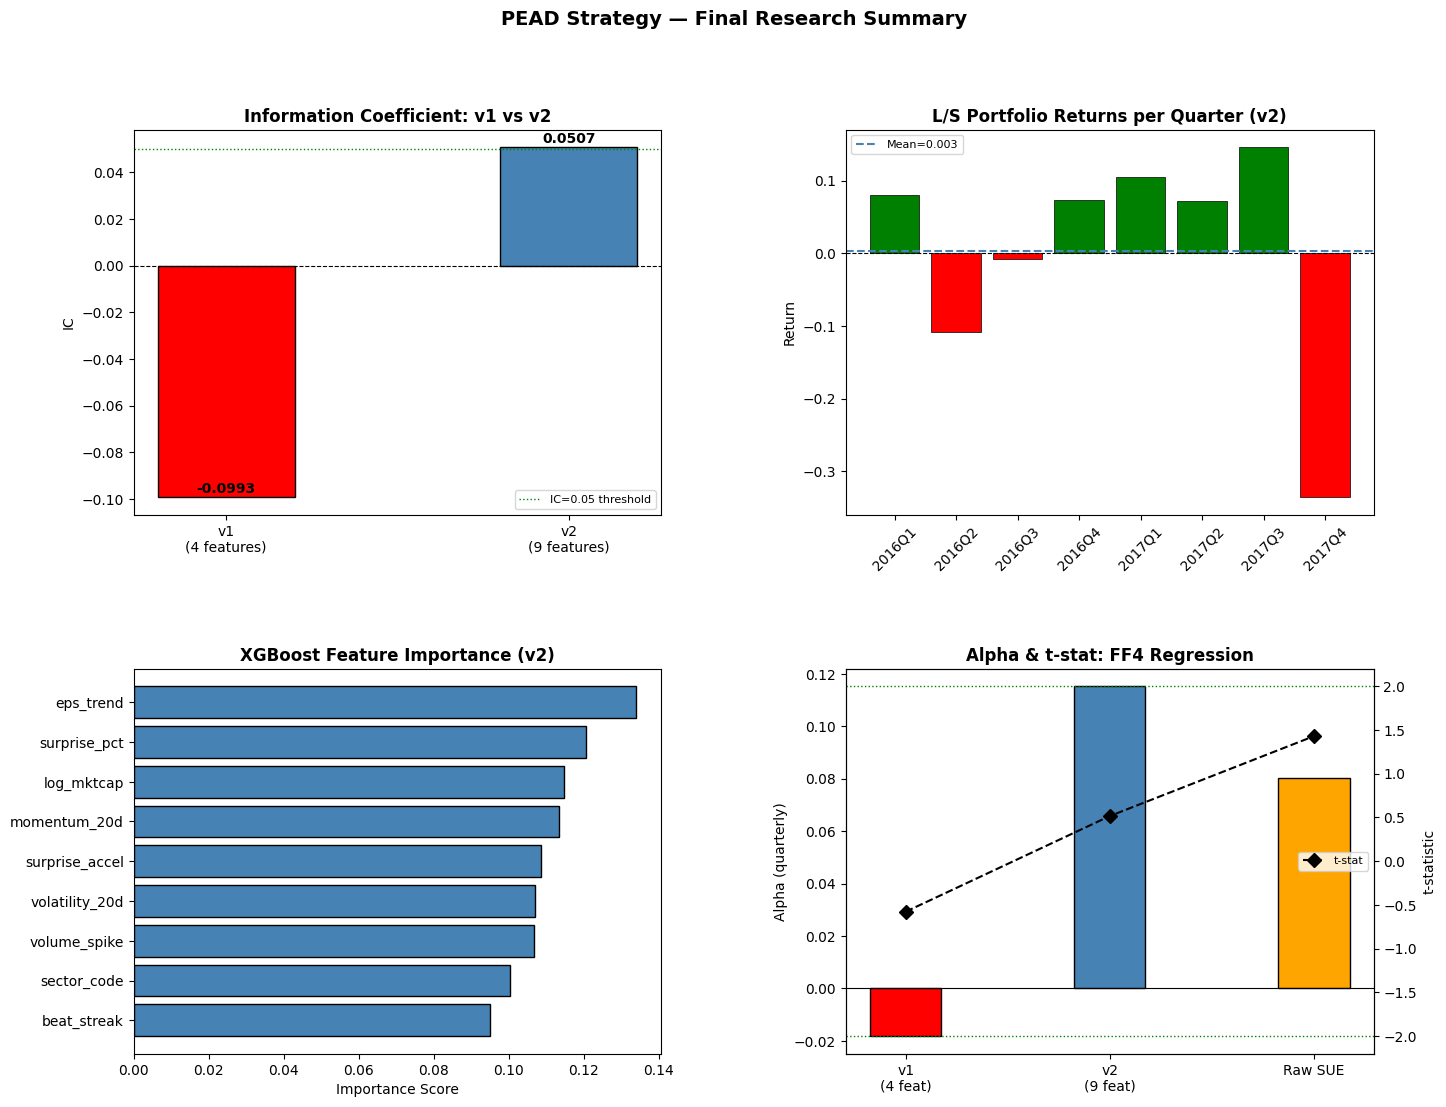

In [24]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# FF3 regression
X3      = sm.add_constant(reg_df[['Mkt_RF','SMB','HML']])
ols_ff3 = sm.OLS(reg_df['excess_ls'], X3).fit()

# FF4 regression
X4      = sm.add_constant(reg_df[['Mkt_RF','SMB','HML','MOM']])
ols_ff4 = sm.OLS(reg_df['excess_ls'], X4).fit()

print(ols_ff4.summary())

print("\n" + "="*55)
print("ALPHA SUMMARY")
print("="*55)
for name, m in [('FF3', ols_ff3), ('FF4', ols_ff4)]:
    a   = m.params['const']
    t   = m.tvalues['const']
    p   = m.pvalues['const']
    sig = "SIGNIFICANT ***" if p < 0.05 else ("MARGINAL *" if p < 0.1 else "NOT significant")
    print(f"{name}: Alpha={a:.4f} | t={t:.3f} | p={p:.3f} | R²={m.rsquared:.3f} | {sig}")

# Feature importance
importance_v2 = pd.Series(model_v2.feature_importances_,
                           index=FEATURES_V2).sort_values(ascending=False)

# Plot
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ic_vals = {'v1\n(4 features)': -0.0993, 'v2\n(9 features)': 0.0507}
colors  = ['red' if v < 0 else 'steelblue' for v in ic_vals.values()]
bars = ax1.bar(ic_vals.keys(), ic_vals.values(), color=colors, width=0.4, edgecolor='black')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.axhline(0.05, color='green', linewidth=1, linestyle=':', label='IC=0.05 threshold')
ax1.set_title('Information Coefficient: v1 vs v2', fontweight='bold')
ax1.set_ylabel('IC')
ax1.legend(fontsize=8)
for bar, val in zip(bars, ic_vals.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.002,
             f'{val:.4f}', ha='center', fontweight='bold')

ax2 = fig.add_subplot(gs[0, 1])
colors_bar = ['green' if x > 0 else 'red' for x in port_v2_df['ls_ret']]
ax2.bar(port_v2_df['quarter'].astype(str), port_v2_df['ls_ret'],
        color=colors_bar, edgecolor='black', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.axhline(port_v2_df['ls_ret'].mean(), color='steelblue',
            linewidth=1.5, linestyle='--', label=f"Mean={port_v2_df['ls_ret'].mean():.3f}")
ax2.set_title('L/S Portfolio Returns per Quarter (v2)', fontweight='bold')
ax2.set_ylabel('Return')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[1, 0])
imp_sorted = importance_v2.sort_values()
ax3.barh(imp_sorted.index, imp_sorted.values, color='steelblue', edgecolor='black')
ax3.set_title('XGBoost Feature Importance (v2)', fontweight='bold')
ax3.set_xlabel('Importance Score')

ax4 = fig.add_subplot(gs[1, 1])
models_  = ['v1\n(4 feat)', 'v2\n(9 feat)', 'Raw SUE']
alphas_  = [-0.0182, ols_ff4.params['const'], 0.0801]
tstats_  = [-0.577,  ols_ff4.tvalues['const'], 1.429]
x        = np.arange(len(models_))
width    = 0.35
ax4.bar(x, alphas_, width, color=['red','steelblue','orange'], edgecolor='black')
ax4_t = ax4.twinx()
ax4_t.plot(x, tstats_, 'D--', color='black', markersize=7, label='t-stat')
ax4_t.axhline(2.0,  color='green', linewidth=1, linestyle=':')
ax4_t.axhline(-2.0, color='green', linewidth=1, linestyle=':')
ax4_t.set_ylabel('t-statistic')
ax4_t.legend(fontsize=8)
ax4.set_xticks(x)
ax4.set_xticklabels(models_)
ax4.axhline(0, color='black', linewidth=0.8)
ax4.set_title('Alpha & t-stat: FF4 Regression', fontweight='bold')
ax4.set_ylabel('Alpha (quarterly)')

plt.suptitle('PEAD Strategy — Final Research Summary', fontsize=14, fontweight='bold')
plt.savefig('research_summary.png', dpi=150, bbox_inches='tight')
plt.show()